# ROC-Based Predictive Analysis: 30-Day Price Movement Classification

This notebook implements a supervised machine learning workflow to predict 30-day price movements using XGBoost classifier.

**Objective:** Create a binary classification target where:
- `1` = Positive ROC (price increase over 30 days)
- `0` = Non-positive ROC (price stagnation or decrease over 30 days)

**Methodology:** Exploratory data analysis, feature engineering, hyperparameter tuning, and model evaluation.


## Initial imports and basic settings

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime


In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}' if abs(x) < 10000 else f'{x:.0f}')
sns.set_style("whitegrid")


## Load data created by data pipeline

Loads the dataset and cleans N/A values created by the pipeline.


In [3]:
df = pd.read_csv('with_indicators.csv', parse_dates=['Date'])

print(f"Total N/A values before cleaning: {df.isna().sum().sum()}")
df.dropna(inplace=True)
print(f"Total N/A values after cleaning: {df.isna().sum().sum()}")

# Sort + clean
df = df.sort_values('Date').reset_index(drop=True)

df['ROC'] = df['ROC'] * 100
df['ROC_30d_future'] = df['ROC'].shift(-30)
df['Price_Direction_30d'] = (df['ROC_30d_future'] > 0).astype(int)

# Drop last rows where future is unknown
df = df.dropna(subset=['ROC_30d_future']).reset_index(drop=True)
df = df.drop(columns=['ROC_30d_future'])

df.head()


Total N/A values before cleaning: 297
Total N/A values after cleaning: 0


,Unnamed: 0,Date,Adj Close,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_12,EMA_26,RSI,MACD,MACD_Signal,BB_Lower,BB_Mid,BB_Upper,ATR,Stoch_K,Stoch_D,OBV,CCI,ROC,Price_Direction_30d
0,49,1999-04-05,0.0380,0.0414,0.0432,0.0411,0.0422,98640000,0.0429,0.0426,0.0425,0.0426,50.3047,-0.0001,0.0000,0.0394,0.0429,0.0465,0.0029,59.0079,60.6463,468576000,-2430.1594,-392.8172,1
1,50,1999-04-06,0.0370,0.0404,0.0419,0.0396,0.0418,69696000,0.0427,0.0426,0.0422,0.0424,48.0056,-0.0003,-0.0000,0.0391,0.0427,0.0464,0.0029,43.7114,53.5454,398880000,-2246.2156,-746.2180,1
2,51,1999-04-07,0.0401,0.0437,0.0440,0.0404,0.0406,89280000,0.0426,0.0426,0.0424,0.0425,55.1791,-0.0001,-0.0000,0.0393,0.0426,0.0460,0.0029,48.0843,50.2679,488160000,-2462.7682,0.0000,1
3,52,1999-04-08,0.0408,0.0445,0.0458,0.0435,0.0440,130128000,0.0426,0.0426,0.0427,0.0427,56.6647,0.0001,-0.0000,0.0393,0.0426,0.0459,0.0029,61.1985,50.9981,618288000,-2537.5295,490.7181,0
4,53,1999-04-09,0.0401,0.0437,0.0448,0.0435,0.0448,48624000,0.0426,0.0427,0.0429,0.0428,54.7118,0.0001,0.0000,0.0393,0.0426,0.0459,0.0028,75.4039,61.5622,569664000,-2526.1455,980.3233,0


## Correlation analysis

As there are many features in the analysis, a separate correlation analysis on just the target variable is performed.



Correlation with Target (Price_Direction_30d):
OBV                      0.0526
Stoch_K                  0.0317
Stoch_D                  0.0296
RSI                      0.0229
ROC                      0.0091
SMA_50                   0.0065
BB_Lower                 0.0057
Close                    0.0050
EMA_26                   0.0049
SMA_20                   0.0044
BB_Mid                   0.0044
EMA_12                   0.0041
BB_Upper                 0.0034
ATR                      0.0009
MACD                    -0.0161
MACD_Signal             -0.0233
CCI                     -0.0333
Volume                  -0.0668


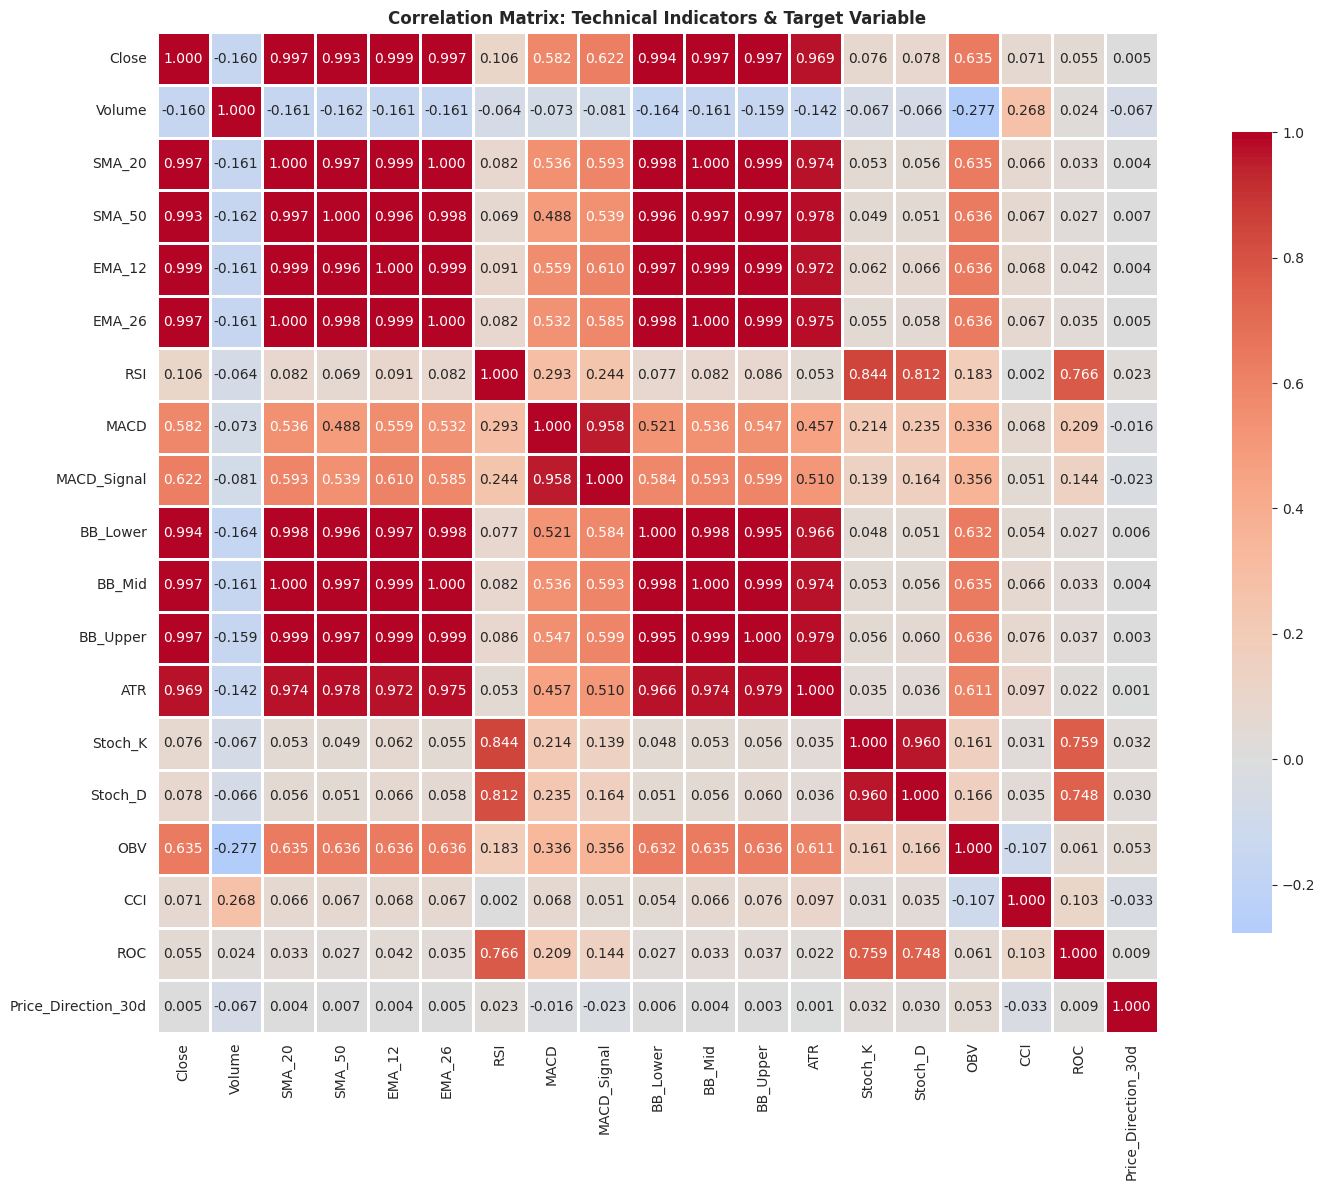

In [4]:
numeric_cols = ['Close', 'Volume', 'SMA_20', 'SMA_50', 'EMA_12',
                'EMA_26', 'RSI', 'MACD', 'MACD_Signal', 'BB_Lower',
                'BB_Mid', 'BB_Upper', 'ATR', 'Stoch_K', 'Stoch_D',
                'OBV', 'CCI', 'ROC', 'Price_Direction_30d']

correlation_matrix = df[numeric_cols].corr()

target_corr = correlation_matrix['Price_Direction_30d'].sort_values(ascending=False)
print("\nCorrelation with Target (Price_Direction_30d):")
for feature, corr_value in target_corr.items():
    if feature != 'Price_Direction_30d':
        print(f"{feature:<20} {corr_value:>10.4f}")

# Visualize correlation heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: Technical Indicators & Target Variable', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()


## Distribution analysis

Visualization of the whole dataset y-value distribution.

Target Class Distribution:
Negative (0): 2765 samples (42.68%)
Positive (1): 3714 samples (57.32%)


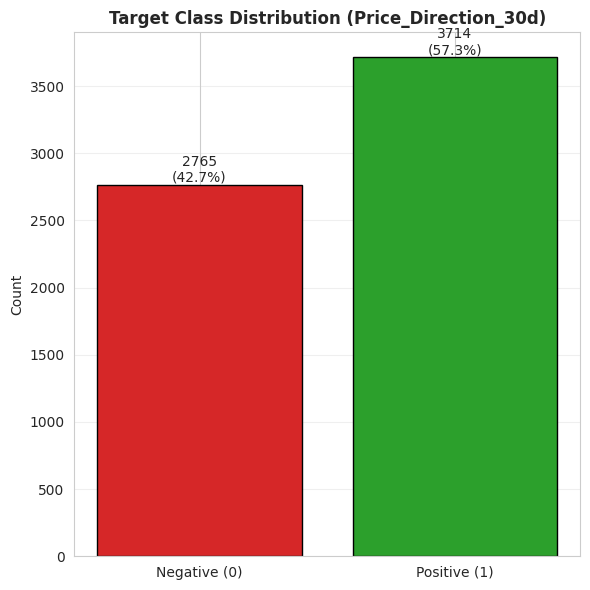

In [5]:
# Get counts and percentages
class_dist = df['Price_Direction_30d'].value_counts().sort_index()
class_pct  = df['Price_Direction_30d'].value_counts(normalize=True).sort_index() * 100

labels = ['Negative (0)', 'Positive (1)']

print("Target Class Distribution:")
for i, label in enumerate(labels):
    count = class_dist.get(i, 0)
    pct   = class_pct.get(i, 0)
    print(f"{label}: {count} samples ({pct:.2f}%)")

fig, ax = plt.subplots(figsize=(6, 6))
bars = ax.bar(labels, [class_dist.get(0, 0), class_dist.get(1, 0)],
              color=['#d62728', '#2ca02c'], edgecolor='black')

ax.set_title('Target Class Distribution (Price_Direction_30d)', fontweight='bold')
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.3)

for bar, label in zip(bars, [0, 1]):
    count = class_dist.get(label, 0)
    pct   = class_pct.get(label, 0)
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f"{count}\n({pct:.1f}%)", ha='center', va='bottom')

plt.tight_layout()
plt.show()


## Visualization - ROC Distribution & Target Variable

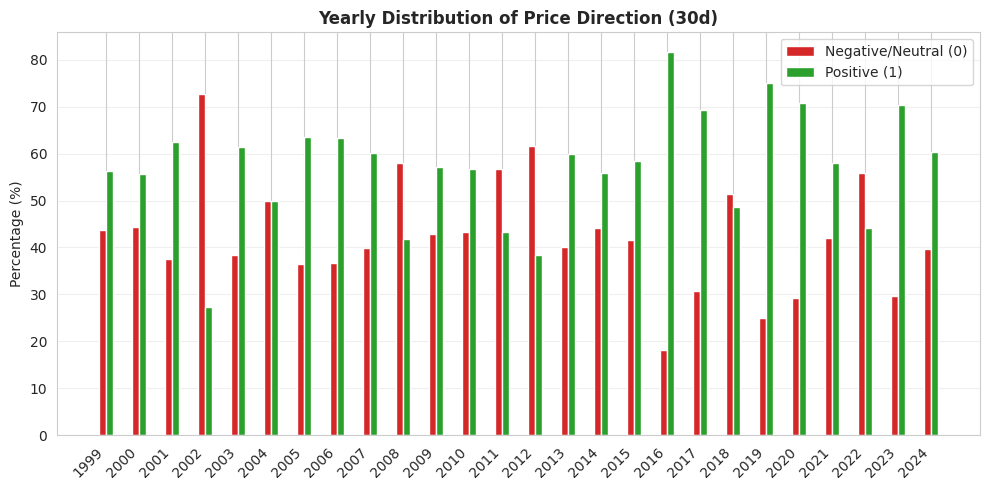

In [6]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year
df_clean = df.dropna(subset=['Year'])

yearly_pct = pd.crosstab(
    df_clean['Year'],
    df_clean['Price_Direction_30d'],
    normalize='index'
) * 100
yearly_pct = yearly_pct.reindex(columns=[0, 1], fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))

spacing = 1.6
x     = [i * spacing for i in range(len(yearly_pct))]
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], yearly_pct[0],
               width, label='Negative/Neutral (0)', color='#d62728')
bars2 = ax.bar([i + width/2 for i in x], yearly_pct[1],
               width, label='Positive (1)', color='#2ca02c')

ax.set_xticks(x)
ax.set_xticklabels(yearly_pct.index.astype(int), rotation=45, ha='right')
ax.set_ylabel('Percentage (%)')
ax.set_title('Yearly Distribution of Price Direction (30d)', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## ROC descriptive statistics

In [7]:
print("=" * 80)
print("ROC (30-DAY) STATISTICAL ANALYSIS")
print("=" * 80)

roc_clean = df['ROC'].dropna()

print(f"\nTotal ROC observations (excluding NaN): {len(roc_clean)}")
print(f"\nDescriptive Statistics:")
print(roc_clean.describe())

print(f"\n{'Metric':<25} {'Value':<15}")
print("-" * 40)
print(f"{'Mean':<25} {roc_clean.mean():<15.4f}")
print(f"{'Median':<25} {roc_clean.median():<15.4f}")
print(f"{'Std Dev':<25} {roc_clean.std():<15.4f}")
print(f"{'Skewness':<25} {roc_clean.skew():<15.4f}")
print(f"{'Kurtosis':<25} {roc_clean.kurtosis():<15.4f}")
print(f"{'Min':<25} {roc_clean.min():<15.4f}")
print(f"{'Max':<25} {roc_clean.max():<15.4f}")
print(f"{'IQR':<25} {roc_clean.quantile(0.75) - roc_clean.quantile(0.25):<15.4f}")


ROC (30-DAY) STATISTICAL ANALYSIS

Total ROC observations (excluding NaN): 6479

Descriptive Statistics:
count    6479.0000
mean      233.7044
std      1312.5185
min     -5471.2797
25%      -480.2292
50%       184.4720
75%       884.3219
max          12874
Name: ROC, dtype: float64

Metric                    Value          
----------------------------------------
Mean                      233.7044       
Median                    184.4720       
Std Dev                   1312.5185      
Skewness                  0.7021         
Kurtosis                  4.5830         
Min                       -5471.2797     
Max                       12873.5153     
IQR                       1364.5510      


## XGBoost Classifier - Model Training & Evaluation

In [8]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve, auc)

# Prepare features and target variable
feature_cols = ['Volume', 'SMA_20', 'SMA_50', 'EMA_12', 'EMA_26', 'RSI',
                'MACD', 'MACD_Signal', 'BB_Lower', 'BB_Mid', 'BB_Upper',
                'ATR', 'Stoch_K', 'Stoch_D', 'OBV', 'CCI']

X = df[feature_cols]
y = df['Price_Direction_30d']

print("=" * 80)
print("DATA PREPARATION FOR XGBOOST")
print("=" * 80)
print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Features used: {len(feature_cols)}")
print(f"Training samples: {len(df)}")

# Split data (80-20 split, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain/Test Split:")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")
print(f"Train target distribution:\n{y_train.value_counts(normalize=True) * 100}")
print(f"\nTest target distribution:\n{y_test.value_counts(normalize=True) * 100}")


DATA PREPARATION FOR XGBOOST

Features shape: (6479, 16)
Target shape: (6479,)
Features used: 16
Training samples: 6479

Train/Test Split:
Training set size: 5183 samples
Testing set size: 1296 samples
Train target distribution:
Price_Direction_30d
1   57.3220
0   42.6780
Name: proportion, dtype: float64

Test target distribution:
Price_Direction_30d
1   57.3302
0   42.6698
Name: proportion, dtype: float64


In [9]:
from sklearn.model_selection import RandomizedSearchCV

# Base model
xgb_base = XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# Hyperparameter space
param_dist = {
    'n_estimators':    [100, 200, 300, 500],
    'max_depth':       [3, 4, 6, 8],
    'learning_rate':   [0.01, 0.03, 0.05, 0.1],
    'subsample':       [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree':[0.6, 0.7, 0.8, 1.0],
    'min_child_weight':[1, 5, 10, 15],
    'reg_alpha':       [0, 0.1, 0.3, 0.5],
    'reg_lambda':      [1, 1.5, 2.0],
    'scale_pos_weight':[1, (y_train==0).sum()/(y_train==1).sum()]
}

# Random search
xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=30,
    scoring='f1',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

# Best model
best_xgb = xgb_search.best_estimator_

print("\nBest Parameters:")
print(xgb_search.best_params_)

# Predictions
y_pred_train = best_xgb.predict(X_train)
y_pred_test  = best_xgb.predict(X_test)
y_pred_proba = best_xgb.predict_proba(X_test)[:, 1]

print("\nTest Performance:")
print(classification_report(y_test, y_pred_test))


Fitting 3 folds for each of 30 candidates, totalling 90 fits



Best Parameters:
{'subsample': 1.0, 'scale_pos_weight': np.float64(0.7445304611242006), 'reg_lambda': 2.0, 'reg_alpha': 0.3, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 8, 'learning_rate': 0.03, 'colsample_bytree': 0.8}

Test Performance:
              precision    recall  f1-score   support

           0       0.81      0.80      0.80       553
           1       0.85      0.86      0.85       743

    accuracy                           0.83      1296
   macro avg       0.83      0.83      0.83      1296
weighted avg       0.83      0.83      0.83      1296



In [10]:
# Model Evaluation
print("=" * 80)
print("MODEL PERFORMANCE METRICS")
print("=" * 80)

# Training metrics
train_accuracy  = accuracy_score(y_train, y_pred_train)
train_precision = precision_score(y_train, y_pred_train)
train_recall    = recall_score(y_train, y_pred_train)
train_f1        = f1_score(y_train, y_pred_train)

# Testing metrics
test_accuracy   = accuracy_score(y_test, y_pred_test)
test_precision  = precision_score(y_test, y_pred_test)
test_recall     = recall_score(y_test, y_pred_test)
test_f1         = f1_score(y_test, y_pred_test)
test_roc_auc    = roc_auc_score(y_test, y_pred_proba)

print(f"\n{'Metric':<20} {'Training':<15} {'Testing':<15}")
print("-" * 50)
print(f"{'Accuracy':<20} {train_accuracy:<15.4f} {test_accuracy:<15.4f}")
print(f"{'Precision':<20} {train_precision:<15.4f} {test_precision:<15.4f}")
print(f"{'Recall':<20} {train_recall:<15.4f} {test_recall:<15.4f}")
print(f"{'F1-Score':<20} {train_f1:<15.4f} {test_f1:<15.4f}")
print(f"{'ROC-AUC':<20} {'N/A':<15} {test_roc_auc:<15.4f}")

print("\n" + "=" * 80)
print("DETAILED CLASSIFICATION REPORT (Test Set)")
print("=" * 80)
print(classification_report(y_test, y_pred_test, target_names=['Negative', 'Positive']))

# Overfitting analysis
print("\n" + "=" * 80)
print("OVERFITTING ANALYSIS")
print("=" * 80)
overfitting_gap = train_accuracy - test_accuracy
print(f"Accuracy gap (Train - Test): {overfitting_gap:.4f}")


MODEL PERFORMANCE METRICS



Metric               Training        Testing        
--------------------------------------------------
Accuracy             0.9707          0.8326         
Precision            0.9793          0.8525         
Recall               0.9694          0.8560         
F1-Score             0.9743          0.8543         
ROC-AUC              N/A             0.8945         

DETAILED CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

    Negative       0.81      0.80      0.80       553
    Positive       0.85      0.86      0.85       743

    accuracy                           0.83      1296
   macro avg       0.83      0.83      0.83      1296
weighted avg       0.83      0.83      0.83      1296


OVERFITTING ANALYSIS
Accuracy gap (Train - Test): 0.1381


FEATURE IMPORTANCE

Top 10 Most Important Features:
    Feature  Importance
     BB_Mid      0.0952
        OBV      0.0882
     EMA_26      0.0871
   BB_Upper      0.0823
     SMA_50      0.0793
   BB_Lower      0.0731
        ATR      0.0680
     EMA_12      0.0678
     SMA_20      0.0652
MACD_Signal      0.0528


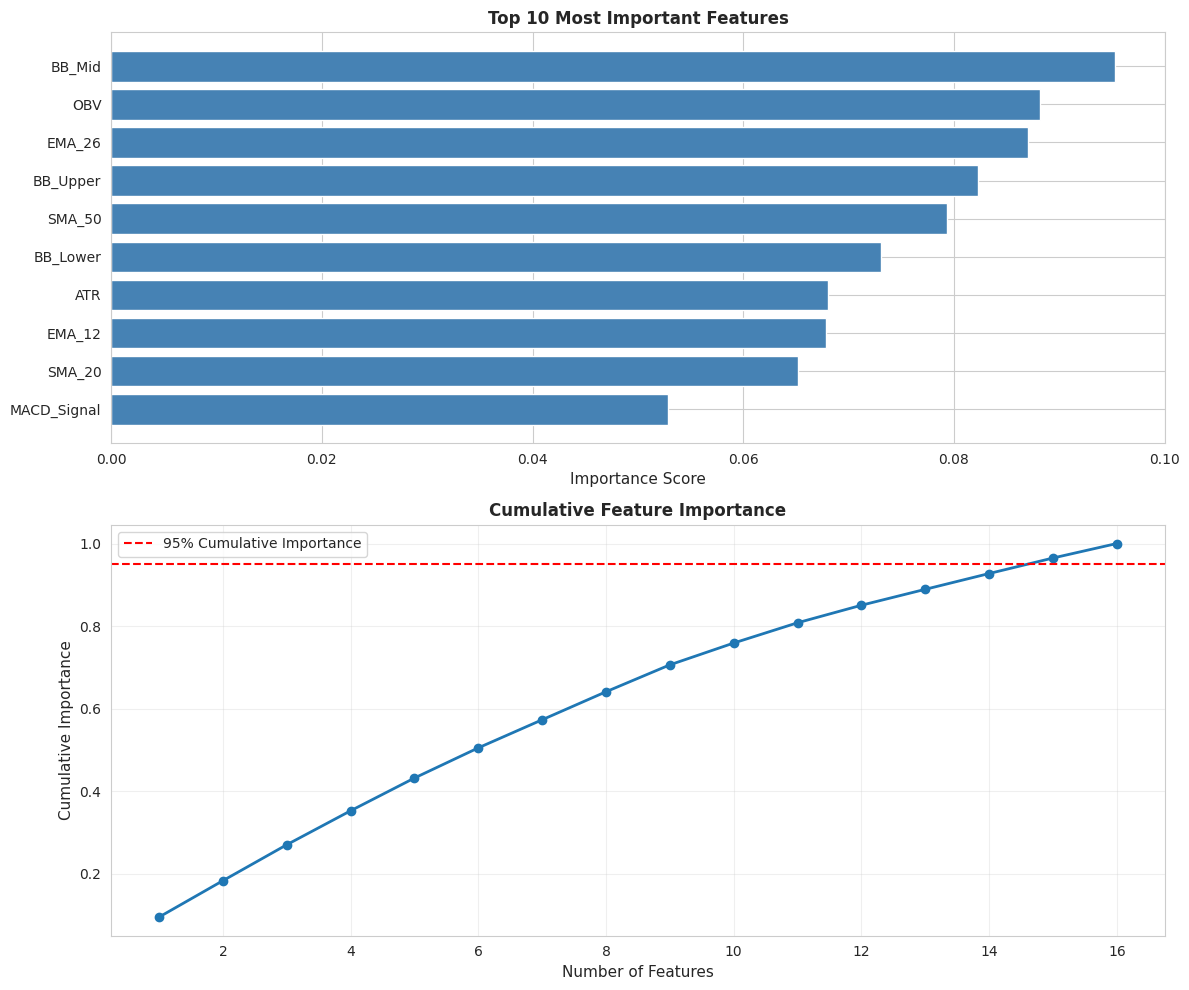


Number of features for 95% cumulative importance: 15


In [11]:
# Feature Importance Analysis
print("=" * 80)
print("FEATURE IMPORTANCE")
print("=" * 80)

feature_importance = pd.DataFrame({
    'Feature':    feature_cols,
    'Importance': best_xgb.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Top 10 bar plot
axes[0].barh(feature_importance.head(10)['Feature'],
             feature_importance.head(10)['Importance'], color='steelblue')
axes[0].set_xlabel('Importance Score', fontsize=11)
axes[0].set_title('Top 10 Most Important Features', fontweight='bold', fontsize=12)
axes[0].invert_yaxis()

# Cumulative importance
cumsum_importance = feature_importance['Importance'].cumsum()
axes[1].plot(range(1, len(cumsum_importance) + 1), cumsum_importance.values,
             marker='o', linestyle='-', linewidth=2)
axes[1].axhline(0.95, color='red', linestyle='--', label='95% Cumulative Importance')
axes[1].set_xlabel('Number of Features', fontsize=11)
axes[1].set_ylabel('Cumulative Importance', fontsize=11)
axes[1].set_title('Cumulative Feature Importance', fontweight='bold', fontsize=12)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

n_features_95 = (cumsum_importance >= 0.95).argmax() + 1
print(f"\nNumber of features for 95% cumulative importance: {n_features_95}")


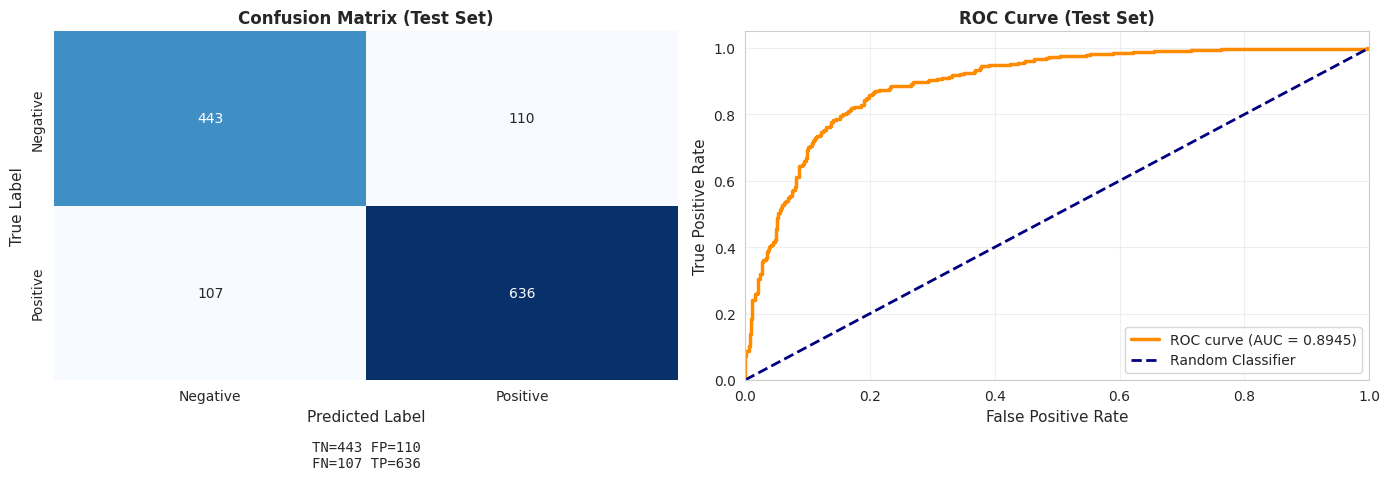

In [12]:
# Confusion Matrix and ROC Curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
axes[0].set_ylabel('True Label', fontsize=11)
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_title('Confusion Matrix (Test Set)', fontweight='bold', fontsize=12)

tn, fp, fn, tp = cm.ravel()
axes[0].text(0.5, -0.25, f'TN={tn} FP={fp}\nFN={fn} TP={tp}',
             transform=axes[0].transAxes, ha='center', fontsize=10, family='monospace')

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc_val = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', lw=2.5,
             label=f'ROC curve (AUC = {roc_auc_val:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title('ROC Curve (Test Set)', fontweight='bold', fontsize=12)
axes[1].legend(loc="lower right", fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [13]:
# Model Summary and Recent Predictions
print("=" * 80)
print("MODEL SUMMARY & PREDICTIONS")
print("=" * 80)

predictions_df = pd.DataFrame({
    'Actual':      y_test.values,
    'Predicted':   y_pred_test,
    'Probability': y_pred_proba,
    'Correct':     y_test.values == y_pred_test
})

print(f"\nTotal Test Predictions: {len(predictions_df)}")
print(f"Correct Predictions: {predictions_df['Correct'].sum()}")
print(f"Incorrect Predictions: {(~predictions_df['Correct']).sum()}")

print("\nRecent Predictions (Last 10 samples):")
print(predictions_df.tail(10).to_string())

# Prediction confidence analysis
print("\n" + "=" * 80)
print("PREDICTION CONFIDENCE ANALYSIS")
print("=" * 80)
high_confidence = (predictions_df['Probability'] >= 0.7) | (predictions_df['Probability'] <= 0.3)
print(f"\nHigh Confidence Predictions (prob >= 0.7 or <= 0.3): {high_confidence.sum()} ({high_confidence.sum()/len(predictions_df)*100:.1f}%)")
print(f"Low Confidence Predictions (0.3 < prob < 0.7): {(~high_confidence).sum()} ({(~high_confidence).sum()/len(predictions_df)*100:.1f}%)")

print("\n✓ XGBoost model complete!")
print("\n" + "=" * 80)
print("KEY TAKEAWAYS")
print("=" * 80)
print(f"• Model Accuracy: {test_accuracy:.2%}")
print(f"• ROC-AUC Score: {test_roc_auc:.4f}")
print(f"• Top Predictor: {feature_importance.iloc[0]['Feature']} (importance: {feature_importance.iloc[0]['Importance']:.4f})")
print(f"• Class Balance: {y_test.value_counts(normalize=True)[1]:.1%} positive signals in test set")
print("=" * 80)


MODEL SUMMARY & PREDICTIONS

Total Test Predictions: 1296
Correct Predictions: 1079
Incorrect Predictions: 217

Recent Predictions (Last 10 samples):
      Actual  Predicted  Probability  Correct
1286       0          1       0.6311    False
1287       0          1       0.6444    False
1288       0          0       0.2771     True
1289       1          1       0.7126     True
1290       1          1       0.8069     True
1291       1          1       0.8032     True
1292       1          1       0.8723     True
1293       1          1       0.9031     True
1294       1          1       0.6215     True
1295       0          0       0.1630     True

PREDICTION CONFIDENCE ANALYSIS

High Confidence Predictions (prob >= 0.7 or <= 0.3): 892 (68.8%)
Low Confidence Predictions (0.3 < prob < 0.7): 404 (31.2%)

✓ XGBoost model complete!

KEY TAKEAWAYS
• Model Accuracy: 83.26%
• ROC-AUC Score: 0.8945
• Top Predictor: BB_Mid (importance: 0.0952)
• Class Balance: 57.3% positive signals in test set